In [1]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib
import IPython.display as ipd

import src.spatial_attn_lightning as binaural_lightning 
import yaml
from pytorch_lightning import Trainer, seed_everything

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# torch.set_float32_matmul_precision('medium')
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True

In [2]:

config_path = "config/binaural_attn/word_task_standard_v06.yaml"
# config_path = "config/binaural_attn/word_task_half_co_loc_v06.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['num_workers'] = 2
config['hparas']['batch_size'] = 32
config['audio']['rep_kwargs']['rep_on_gpu'] = True
print(config['hparas']['lr'])


0.01


In [32]:
seed_everything(0)
importlib.reload(binaural_lightning)
module = binaural_lightning.BinauralAttentionModule(config)

[rank: 0] Seed set to 0


num_classes={'num_words': 800}
Model performing word task
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [33]:
# Make sure _collate function doesn't do something strange
train_dataset = module.dataset(**module.corpora_config,
                                batch_size=config['hparas']['batch_size'] ,
                                mode='train')
train_dataloader = module.train_dataloader()

Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v06
cue type: voice_and_location
985 files in train concat dataset
Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v06
cue type: voice_and_location
985 files in train concat dataset
len training set = 123125


In [116]:
loader = iter(train_dataloader)
for i in range(2):
    dl_batch = next(loader)

1
1
1
1


1
1


In [117]:
ds_batch = train_dataset[i]


In [118]:
ds_batch

(array([[[-3.7717104e-02, -3.0497398e-02, -2.4354624e-02, ...,
           3.8755382e-03,  4.8023090e-03,  4.3659220e-03],
         [-4.9094041e-03, -1.3097842e-02, -1.5102734e-02, ...,
          -9.6309735e-03, -1.3365055e-02, -1.5498628e-02]],
 
        [[-3.5059943e-06, -3.5045823e-06, -3.5017451e-06, ...,
           9.4096353e-03,  7.1479515e-03,  8.3275381e-03],
         [-3.5082905e-06, -3.5043722e-06, -3.5006851e-06, ...,
           6.5192217e-03,  5.8249761e-03,  4.4730166e-03]],
 
        [[-1.5024565e-02, -1.6658135e-02, -1.7673282e-02, ...,
           5.8464576e-03,  5.9633316e-03,  6.0723745e-03],
         [-1.8020401e-02, -1.2328418e-02, -4.3351753e-03, ...,
          -8.0289869e-03, -1.0459969e-02, -1.2945138e-02]],
 
        ...,
 
        [[-4.0559435e-06, -4.0570280e-06, -4.0561149e-06, ...,
           8.6381417e-03,  1.2168953e-02,  1.5415202e-02],
         [-4.0652794e-06, -4.0585342e-06, -4.0617501e-06, ...,
          -8.8628484e-03, -9.0638380e-03, -7.7529442e-03]],

In [122]:
labels

tensor([ 27, 480, 336, 755, 405, 551, 552,  70, 721, 764, 252, 733, 449, 158,
        755, 485, 129, 701,  74, 218,  45, 764, 750, 190, 146, 642, 333, 287,
        758,   6, 583, 587])

In [120]:
cue_sig, target_sig, distractor_sig, label_int = ds_batch

In [121]:
cues, mask, scenes, labels = dl_batch

In [128]:
eg_ix = 0
print("ds cue audio")
ipd.display(ipd.Audio(cue_sig[eg_ix], rate=44100, normalize=False))
print("dl cue audio")
ipd.display(ipd.Audio(cues[eg_ix], rate=44100, normalize=False))

print("ds scene audio")
ds_scene, _ = module.audio_transforms(target_sig[eg_ix], distractor_sig[eg_ix])
ipd.display(ipd.Audio(ds_scene, rate=44100, normalize=False))
print("dl scene audio")
ipd.display(ipd.Audio(scenes[eg_ix], rate=44100, normalize=False))
print(label_int[eg_ix], labels[eg_ix])

ds cue audio


dl cue audio


ds scene audio


dl scene audio


27 tensor(27)


In [126]:
## check cochleagrams
ch_gram = module.coch_gram.cuda()
ds_scenes, _ = module.audio_transforms(target_sig, distractor_sig)

ds_cue_gram, ds_scene_gram = ch_gram(torch.from_numpy(cue_sig).cuda(),
                                     ds_scenes.cuda())

dl_cue_gram, dl_scene_gram = ch_gram(cues.cuda(), scenes.cuda())

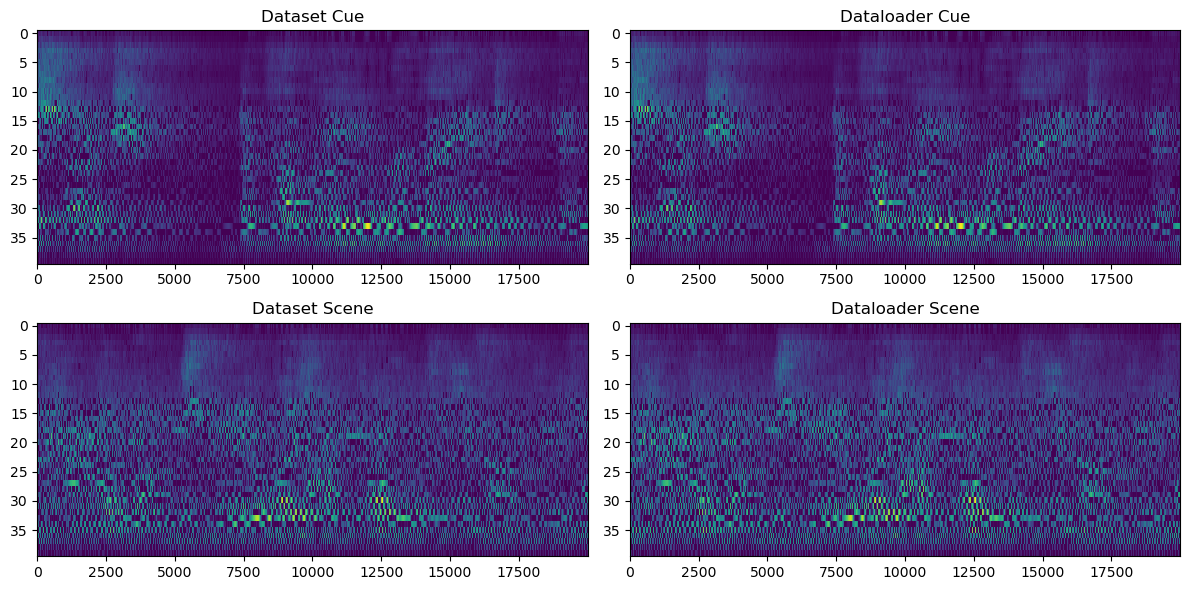

In [127]:
## Show grams
%matplotlib inline
import matplotlib.pyplot as plt 

fig, axs = plt.subplots(2,2, figsize=(12,6))
axs = axs.ravel()
axs[0].imshow(ds_cue_gram[0,0].cpu(), aspect='auto', interpolation='none')
axs[1].imshow(dl_cue_gram[0,0].cpu(), aspect='auto', interpolation='none')
axs[0].set_title("Dataset Cue")
axs[1].set_title("Dataloader Cue")

axs[2].imshow(ds_scene_gram[0,0].cpu(), aspect='auto', interpolation='none')
axs[3].imshow(dl_scene_gram[0,0].cpu(), aspect='auto', interpolation='none')
axs[2].set_title("Dataset Scene")
axs[3].set_title("Dataloader Scene")
plt.tight_layout()

In [5]:
kaiming_init(module, mode='fan_in', init_type='uniform')

In [6]:
trainer = Trainer(
    precision="32",
    limit_val_batches=0.0,
    num_nodes=1,
    # benchmark=True,
    devices=1, # was gpus=1,
    # detect_anomaly=True,
    # strategy="ddp_notebook",
    accelerator="gpu",
)
trainer.fit(module)

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /om2/user/imgriff/conda_envs/pytorch_2/lib/python3.1 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                         | Params
------------------------------------------------------------------
0 | audio_transforms | AudioCompose                 | 0     
1 | model            | OptimizedModule      

Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v06
cue type: mixed
mixture_percentages={'voice_only': 0.5, 'voice_and_location': 0.5}
985 files in train concat dataset
len training set = 123125
Epoch 0:   0%|          | 63/123125 [02:48<91:29:20,  0.37it/s, v_num=3.47e+7, train_loss=6.690, grad_norm=0.398] 

In [ ]:
## Check dataset 

dataset = module.dataset(**config['corpus'], mode='train')

In [ ]:
cue, target, distractor, labels = dataset[0]

In [ ]:
aud_transforms = module.audio_transforms

In [ ]:
ix = 1080

cue, target, distractor, labels = dataset[ix]

scene, _ = aud_transforms(target, distractor)

print("cue")
ipd.display(ipd.Audio(cue[0], rate=44100, normalize=False))
print("target")
ipd.display(ipd.Audio(target[0], rate=44100, normalize=False))
print("distractor")
ipd.display(ipd.Audio(distractor[0], rate=44100, normalize=False))
print("scene")
ipd.display(ipd.Audio(scene[0], rate=44100, normalize=False))